In [1]:
### Cell 1: Install Dependencies

# If not installed, uncomment:
# !pip install torch torchvision  # if you need GPU builds, please see PyTorch website
# !pip install transformers datasets
# !pip install scikit-learn

In [2]:
# Cell 2: Imports and Basic Setup

import math
import numpy as np
import torch
import torch.nn as nn
import requests  # only if you want direct download from e.g. Hugging Face
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# HF Transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

# HuggingFace 'datasets' for The Pile
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 3: Helper function: get_model_name(suite, size, deduped)
def get_model_name(suite, size, deduped=False):
    """
    Return the HF model name for pythia or GPT-Neo, with deduped if relevant.
    """
    suite = suite.lower()
    size = size.lower()
    if suite == "pythia":
        # e.g. pythia-70m or pythia-70m-deduped
        if size == "70m":
            return f"EleutherAI/pythia-70m{'-deduped' if deduped else ''}"
        elif size == "160m":
            return f"EleutherAI/pythia-160m{'-deduped' if deduped else ''}"
        elif size == "1.4b":
            return f"EleutherAI/pythia-1.4b{'-deduped' if deduped else ''}"
        elif size == "2.8b":
            return f"EleutherAI/pythia-2.8b{'-deduped' if deduped else ''}"
        elif size == "6.9b":
            return f"EleutherAI/pythia-6.9b{'-deduped' if deduped else ''}"
        elif size == "12b":
            return f"EleutherAI/pythia-12b{'-deduped' if deduped else ''}"
        else:
            raise ValueError(f"Unsupported pythia size: {size}")
    elif suite=="gpt-neo":
        if size=="125m":
            return "EleutherAI/gpt-neo-125M"
        elif size=="1.3b":
            return "EleutherAI/gpt-neo-1.3B"
        elif size=="2.7b":
            return "EleutherAI/gpt-neo-2.7B"
        else:
            raise ValueError(f"Unsupported gpt-neo size: {size}")
    else:
        raise ValueError(f"Unknown suite: {suite}")

In [12]:
# ------------------------------------------------------------------------------
# Cell 4: GPU-Friendly, BATCHED Implementation of Next-token Loss & Signal Extraction
# ------------------------------------------------------------------------------

@torch.no_grad()
def compute_next_token_losses_batch(
    texts,
    model,
    tokenizer,
    device="cuda",
    max_length=1024
):
    """
    Given a list of text strings, this function:
      - Tokenizes them (truncation up to max_length)
      - Runs a single forward pass on the GPU for the entire batch
      - Computes a next-token cross-entropy loss for each token
      - Returns a list of 'loss sequences', where each element
        is the per-token loss array for that text.

    This replaces the old single-text approach.
    """
    if len(texts)==0:
        return []

    # Tokenize with padding/truncation
    enc = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    # We do one forward pass for the entire batch
    outputs = model(input_ids, labels=input_ids, attention_mask=attention_mask)
    logits = outputs.logits  # shape: [batch_size, seq_len, vocab_size]
    # Next-token prediction => shift
    logits = logits[:, :-1, :]  
    target = input_ids[:, 1:]
    mask   = attention_mask[:, 1:]

    # Flatten for cross-entropy
    bsz, seq_len_minus1, vocab_size = logits.shape
    logits_flat = logits.reshape(-1, vocab_size)  # [bsz*(seq_len-1), vocab_size]
    target_flat = target.reshape(-1)

    loss_fct = nn.CrossEntropyLoss(reduction='none')
    token_losses_flat = loss_fct(logits_flat, target_flat)
    token_losses = token_losses_flat.view(bsz, seq_len_minus1)

    # Now for each item in the batch, we slice out only the valid (non-pad) tokens
    loss_seq_list = []
    for i in range(bsz):
        valid_len = int(mask[i].sum().item())  # how many tokens are valid
        # we have next-token losses for valid_len - 1 positions
        eff_len = max(0, valid_len - 1)
        seq_losses = token_losses[i, :eff_len].tolist()
        loss_seq_list.append(seq_losses)

    return loss_seq_list

def replicate_if_short(seq, desired_len):
    out = list(seq)
    while len(out)<desired_len:
        out += seq
    return out

def slope_signal(loss_seq, Tprime=200):
    arr = list(loss_seq)
    # replicate if short
    if len(arr)<Tprime:
        repeats = (Tprime//len(arr)) + 1
        arr = arr*repeats
    arr = arr[:Tprime]
    if len(arr)<2:
        return 0.0
    x_vals = np.arange(len(arr))
    y_vals = np.array(arr)
    mean_x = x_vals.mean()
    mean_y = y_vals.mean()
    numerator   = np.sum((x_vals-mean_x)*(y_vals-mean_y))
    denominator = np.sum((x_vals-mean_x)**2)
    if abs(denominator)<1e-12:
        return 0.0
    return float(numerator/denominator)

def approximate_entropy(loss_seq, Tprime=200, m=8, r=0.8):
    arr = list(loss_seq)
    if len(arr)==0:
        return 0.0
    # replicate if short
    if len(arr)<Tprime:
        repeats = (Tprime//len(arr)) + 1
        arr = arr*repeats
    arr = arr[:Tprime]

    vals = np.array(arr)
    n = len(vals)
    if n<(m+1):
        return 0.0

    def _maxdist(a,b):
        return np.max(np.abs(a-b))

    x_m = [vals[i:i+m] for i in range(n-m+1)]
    c=[]
    for i in range(len(x_m)):
        cnt=0
        for j in range(len(x_m)):
            if _maxdist(x_m[i], x_m[j])<=r:
                cnt+=1
        c.append(cnt/len(x_m))
    phi_m = np.mean(np.log(np.array(c)+1e-9))

    if n<(m+1+1):
        return 0.0
    x_m2 = [vals[i:i+m+1] for i in range(n-(m+1)+1)]
    c2=[]
    for i in range(len(x_m2)):
        cnt=0
        for j in range(len(x_m2)):
            if _maxdist(x_m2[i], x_m2[j])<=r:
                cnt+=1
        c2.append(cnt/len(x_m2))
    phi_m2 = np.mean(np.log(np.array(c2)+1e-9))
    return float(phi_m - phi_m2)

def token_diversity(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    if len(tokens)==0:
        return 0.0
    return len(set(tokens))/len(tokens)

def gather_signals_for_batch(texts, model, tokenizer, device="cuda", max_length=1024):
    """
    Batches the next-token loss computation for:
      - original texts
      - repeated 2x
      - repeated 3x
    Then computes membership signals offline from those 3 sets of loss sequences.

    Returns: a list of dicts, one per text in 'texts'.
    """
    # repeated versions
    rep2_texts = [t + " " + t for t in texts]
    rep3_texts = [t + " " + t + " " + t for t in texts]

    # 1) original
    orig_lossseqs = compute_next_token_losses_batch(
        texts, model, tokenizer, device, max_length
    )
    # 2) repeated 2x
    rep2_lossseqs = compute_next_token_losses_batch(
        rep2_texts, model, tokenizer, device, max_length
    )
    # 3) repeated 3x
    rep3_lossseqs = compute_next_token_losses_batch(
        rep3_texts, model, tokenizer, device, max_length
    )

    results = []
    for i, original_text in enumerate(texts):
        seq_orig = orig_lossseqs[i]
        seq_rep2 = rep2_lossseqs[i]
        seq_rep3 = rep3_lossseqs[i]

        def cutoff_loss(loss_seq, Tprime=None):
            if len(loss_seq)==0:
                return float('inf')
            if Tprime is None or Tprime>len(loss_seq):
                return float(np.mean(loss_seq))
            return float(np.mean(loss_seq[:Tprime]))

        cut_all  = cutoff_loss(seq_orig, None)
        cut_200  = cutoff_loss(seq_orig, 200)
        cut_300  = cutoff_loss(seq_orig, 300)
        rep2_all = cutoff_loss(seq_rep2, None)
        rep2_200 = cutoff_loss(seq_rep2, 200)
        rep2_300 = cutoff_loss(seq_rep2, 300)
        rep3_all = cutoff_loss(seq_rep3, None)
        rep3_200 = cutoff_loss(seq_rep3, 200)
        rep3_300 = cutoff_loss(seq_rep3, 300)

        sdict = {}
        sdict["cut_all"]  = cut_all
        sdict["cut_200"]  = cut_200
        sdict["cut_300"]  = cut_300

        sdict["cut_all_rep1_diff"]  = cut_all - rep2_all
        sdict["cut_all_rep2_diff"]  = cut_all - rep3_all
        sdict["cut_200_rep1_diff"]  = cut_200 - rep2_200
        sdict["cut_200_rep2_diff"]  = cut_200 - rep3_200
        sdict["cut_300_rep1_diff"]  = cut_300 - rep2_300
        sdict["cut_300_rep2_diff"]  = cut_300 - rep3_300

        div = token_diversity(original_text, tokenizer)
        def safe_div(x, d):
            if d < 1e-9:
                return float('inf')
            return x/d

        # calibrations
        sdict["cal_all"] = safe_div(cut_all, div)
        sdict["cal_200"] = safe_div(cut_200, div)
        sdict["cal_300"] = safe_div(cut_300, div)

        sdict["cal_all_rep1_diff"] = sdict["cal_all"] - safe_div(rep2_all, div)
        sdict["cal_all_rep2_diff"] = sdict["cal_all"] - safe_div(rep3_all, div)
        sdict["cal_200_rep1_diff"] = sdict["cal_200"] - safe_div(rep2_200, div)
        sdict["cal_200_rep2_diff"] = sdict["cal_200"] - safe_div(rep3_200, div)
        sdict["cal_300_rep1_diff"] = sdict["cal_300"] - safe_div(rep2_300, div)
        sdict["cal_300_rep2_diff"] = sdict["cal_300"] - safe_div(rep3_300, div)

        # slope & approx entropy
        for Tprime in [600,800,1000]:
            sdict[f"slope_{Tprime}"] = slope_signal(seq_orig, Tprime)
            sdict[f"apen_{Tprime}"]  = approximate_entropy(seq_orig, Tprime, 8, 0.8)

        # perplexities
        def safe_exp(x):
            return math.exp(x) if x!=float('inf') else float('inf')

        ppl_all   = safe_exp(cut_all)
        ppl_200   = safe_exp(cut_200)
        ppl_300   = safe_exp(cut_300)
        rep2_ppl_all = safe_exp(rep2_all)
        rep2_ppl_200 = safe_exp(rep2_200)
        rep2_ppl_300 = safe_exp(rep2_300)
        rep3_ppl_all = safe_exp(rep3_all)
        rep3_ppl_200 = safe_exp(rep3_200)
        rep3_ppl_300 = safe_exp(rep3_300)

        sdict["ppl_all"] = ppl_all
        sdict["ppl_200"] = ppl_200
        sdict["ppl_300"] = ppl_300

        sdict["ppl_all_rep1_diff"]  = ppl_all - rep2_ppl_all
        sdict["ppl_all_rep2_diff"]  = ppl_all - rep3_ppl_all
        sdict["ppl_200_rep1_diff"]  = ppl_200 - rep2_ppl_200
        sdict["ppl_200_rep2_diff"]  = ppl_200 - rep3_ppl_200
        sdict["ppl_300_rep1_diff"]  = ppl_300 - rep2_ppl_300
        sdict["ppl_300_rep2_diff"]  = ppl_300 - rep3_ppl_300

        calppl_all  = safe_div(ppl_all,  div)
        calppl_200  = safe_div(ppl_200,  div)
        calppl_300  = safe_div(ppl_300,  div)
        rep2_calppl_all  = safe_div(rep2_ppl_all, div)
        rep3_calppl_all  = safe_div(rep3_ppl_all, div)
        rep2_calppl_200  = safe_div(rep2_ppl_200, div)
        rep3_calppl_200  = safe_div(rep3_ppl_200, div)
        rep2_calppl_300  = safe_div(rep2_ppl_300, div)
        rep3_calppl_300  = safe_div(rep3_ppl_300, div)

        sdict["calppl_all"] = calppl_all
        sdict["calppl_200"] = calppl_200
        sdict["calppl_300"] = calppl_300

        sdict["calppl_all_rep1_diff"]  = calppl_all - rep2_calppl_all
        sdict["calppl_all_rep2_diff"]  = calppl_all - rep3_calppl_all
        sdict["calppl_200_rep1_diff"]  = calppl_200 - rep2_calppl_200
        sdict["calppl_200_rep2_diff"]  = calppl_200 - rep3_calppl_200
        sdict["calppl_300_rep1_diff"]  = calppl_300 - rep2_calppl_300
        sdict["calppl_300_rep2_diff"]  = calppl_300 - rep3_calppl_300

        # For demonstration, let's keep count_below_x and LZ for original only
        def count_below_threshold(seq, threshold, Tprime=200):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)==0:
                return 0.0
            return sum(1 for x in arr if x<=threshold)/len(arr)

        sdict["cb_const1"] = count_below_threshold(seq_orig, 1, 200)
        sdict["cb_const2"] = count_below_threshold(seq_orig, 2, 200)
        sdict["cb_const3"] = count_below_threshold(seq_orig, 3, 200)

        def count_below_mean(seq, Tprime=200):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)==0:
                return 0.0
            avgv = np.mean(arr)
            return sum(1 for x in arr if x<=avgv)/len(arr)
        sdict["cb_mean"] = count_below_mean(seq_orig, 200)

        def count_below_prev_mean(seq, Tprime=200):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)<2:
                return 0.0
            c=0
            running_sum = 0.0
            for idx, val in enumerate(arr):
                if idx==0:
                    running_sum+=val
                    continue
                pm = running_sum/idx
                if val<=pm:
                    c+=1
                running_sum+=val
            total = len(arr)-1
            return c/total if total>0 else 0.0

        sdict["cb_prev_mean"] = count_below_prev_mean(seq_orig, 200)

        def lempel_ziv_complexity(seq, Tprime=200, bins=3):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)==0:
                return 0.0
            arr = np.array(arr)
            mn, mx = arr.min(), arr.max()
            if abs(mx-mn)<1e-12:
                return 1.0
            bin_edges = np.linspace(mn, mx+1e-9, bins)
            codes = np.digitize(arr, bin_edges)
            s = "".join(chr(int(c)+65) for c in codes)
            i=0
            c=1
            length=len(s)
            while i<length-1:
                sub = s[i:i+1]
                while (s[i:i+len(sub)] in s[:i]) and (i+len(sub)<length):
                    sub += s[i+len(sub)]
                i+=len(sub)
                c+=1
            return float(c)

        for nb in [3,4,5]:
            sdict[f"lz_bins{nb}"] = lempel_ziv_complexity(seq_orig, 200, nb)

        results.append(sdict)
    return results

def gather_signals_for_dataset(
    texts,
    model,
    tokenizer,
    device="cuda",
    max_length=1024,
    batch_size=8
):
    """
    For a large list of texts, we chunk them into batches of size `batch_size`,
    pass each batch to gather_signals_for_batch, and accumulate the results.

    Returns: a list of dicts, same length as `texts`.
    """
    all_sdicts = []
    for start_i in range(0, len(texts), batch_size):
        end_i = start_i + batch_size
        batch_texts = texts[start_i:end_i]
        batch_sigs = gather_signals_for_batch(
            batch_texts, model, tokenizer, device, max_length
        )
        all_sdicts.extend(batch_sigs)
    return all_sdicts

In [5]:
# ------------------------------------------------------------------------------
# Cell 5: (unchanged) – We keep all prior code or skip if user had no code
# ------------------------------------------------------------------------------

In [6]:
# ------------------------------------------------------------------------------
# Cell 6: Two Attack Approaches, updated to gather signals in BATCH
# ------------------------------------------------------------------------------
import bisect

def edgington_fit(nonmember_texts, model, tokenizer, device, batch_size=8):
    """
    Build reference distribution from nonmembers *in batch*.
    Returns ref_dict: {signal_name: sorted array of values}.
    """
    from collections import defaultdict
    ref_dict = defaultdict(list)

    # 1) gather signals for nonmembers in batch
    nm_sdicts = gather_signals_for_dataset(nonmember_texts, model, tokenizer, device, batch_size=batch_size)

    # 2) build reference distribution
    for sdict in nm_sdicts:
        for k,v in sdict.items():
            ref_dict[k].append(v)
    for k in ref_dict.keys():
        ref_dict[k] = np.sort(ref_dict[k])
    return ref_dict

def edgington_score_batch(texts, model, tokenizer, device, ref_dict, batch_size=8):
    """
    Compute Edgington membership scores for a list of texts in batch.
    Return: list of float scores, one per text.
    """
    results = []
    # gather signals for these texts in batch
    sdicts = gather_signals_for_dataset(texts, model, tokenizer, device, batch_size=batch_size)
    for sdict in sdicts:
        total = 0.0
        for k,v in sdict.items():
            arr = ref_dict.get(k, None)
            if arr is None or len(arr)==0:
                continue
            idx = bisect.bisect_right(arr, v)
            frac = idx/len(arr)
            total += frac
        results.append(total)
    return results


def logistic_fit(member_texts, nonmember_texts, model, tokenizer, device, batch_size=8):
    """
    1) gather signals for all texts in batch
    2) label members=1, nonmembers=0
    3) define group tags, apply groupwise PCA
    4) logistic regression
    Returns (clf, all_keys, group2pca, group_tags)
    """
    # gather
    Xdicts = []
    Y = []

    mem_sdicts = gather_signals_for_dataset(member_texts, model, tokenizer, device, batch_size=batch_size)
    for d in mem_sdicts:
        Xdicts.append(d)
        Y.append(1)
    nm_sdicts = gather_signals_for_dataset(nonmember_texts, model, tokenizer, device, batch_size=batch_size)
    for d in nm_sdicts:
        Xdicts.append(d)
        Y.append(0)

    # consistent feature order
    all_keys = sorted(list(Xdicts[0].keys()))
    # build array
    Xmat=[]
    for rowdict in Xdicts:
        row=[]
        for k in all_keys:
            row.append(rowdict[k])
        Xmat.append(row)
    Xmat = np.array(Xmat,dtype=float)
    Y = np.array(Y,dtype=int)

    # group tags
    def group_of(k):
        if k.startswith("cut"):
            return "cut"
        elif k.startswith("calppl"):
            return "calppl"
        elif k.startswith("ppl"):
            return "ppl"
        elif k.startswith("cal_"):
            return "cal"
        elif k.startswith("cb_const"):
            return "cbconst"
        elif k.startswith("cb_mean"):
            return "cbmean"
        elif k.startswith("cb_prev_mean"):
            return "cbpm"
        elif k.startswith("lz_bins"):
            return "lz"
        elif k.startswith("slope"):
            return "slope"
        elif k.startswith("apen"):
            return "apen"
        else:
            return "misc"

    from collections import defaultdict
    group_tags = {}
    for k in all_keys:
        group_tags[k] = group_of(k)

    group2cols = defaultdict(list)
    for i,k in enumerate(all_keys):
        grp = group_tags[k]
        group2cols[grp].append(i)

    # apply PCA
    group2pca = {}
    newXlist = []
    for _ in range(len(Xmat)):
        newXlist.append([])

    pca_components_per_group = 2
    from sklearn.decomposition import PCA

    for grp, idxs in group2cols.items():
        subX = Xmat[:, idxs]
        if subX.shape[1]==1:
            # keep as is
            for row_i in range(len(Xmat)):
                newXlist[row_i].append(subX[row_i,0])
            group2pca[grp] = None
        else:
            pca = PCA(n_components=min(pca_components_per_group, subX.shape[1]))
            pca.fit(subX)
            trans = pca.transform(subX)
            for row_i in range(len(Xmat)):
                newXlist[row_i].extend(list(trans[row_i]))
            group2pca[grp] = pca

    finalX = np.array(newXlist, dtype=float)
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    clf.fit(finalX, Y)
    return clf, all_keys, group2pca, group_tags

def logistic_score_batch(texts, model, tokenizer, device, clf, all_keys, group2pca, group_tags, batch_size=8):
    """
    Compute logistic membership scores for a list of texts in batch
    using the trained logistic model and groupwise PCA transform.

    Return: list of membership scores (float).
    """
    sdicts = gather_signals_for_dataset(texts, model, tokenizer, device, batch_size=batch_size)
    results = []
    for rowdict in sdicts:
        row=[]
        for k in all_keys:
            row.append(rowdict[k])
        row = np.array(row,dtype=float).reshape(1,-1)

        # replicate groupwise PCA
        from collections import defaultdict
        groupvals = defaultdict(list)
        for i,k in enumerate(all_keys):
            grp = group_tags[k]
            groupvals[grp].append(row[0, i])

        newrow=[]
        for grp, pca in group2pca.items():
            arr = np.array(groupvals[grp]).reshape(1,-1)
            if pca is None:
                newrow.extend(list(arr[0]))
            else:
                out = pca.transform(arr)
                newrow.extend(list(out[0]))
        newrow = np.array(newrow).reshape(1,-1)
        prob = clf.predict_proba(newrow)[0,1]
        score = -prob  # smaller => membership-likely
        results.append(score)
    return results

In [7]:
# ------------------------------------------------------------------------------
# Cell 7: Utility for metrics
# ------------------------------------------------------------------------------
def compute_metrics_and_show(mem_scores, nm_scores):
    """
    We'll compute:
     - AUC
     - TPR at 1%FPR
     We'll also optionally plot an ROC curve.
    """
    import numpy as np
    from sklearn.metrics import roc_auc_score

    ytrue = np.array([1]*len(mem_scores) + [0]*len(nm_scores))
    yscore= np.concatenate([mem_scores, nm_scores], axis=0)

    # We want "smaller => membership-likely," so let's invert the sign for standard AUC logic:
    # Typically AUC logic is "higher => membership-likely."
    # We'll do yscore_invert = - yscore
    # so that bigger => membership-likely
    yscore_invert = -yscore

    auc_val = roc_auc_score(ytrue, yscore_invert)

    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(ytrue, yscore_invert)
    # find closest fpr to 0.01
    idx = np.argmin(np.abs(fpr-0.01))
    tpr_001fpr = tpr[idx]

    print(f"AUC = {auc_val:.4f}")
    print(f"TPR@1%FPR = {tpr_001fpr*100:.2f}%")

    # Optional: we can also do direct plotting of the ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc_val:.4f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.title("ROC curve (inverted membership scores => +ve label=member)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return auc_val, tpr_001fpr

Fetching model name...
Loading tokenizer & model: EleutherAI/pythia-70m
Loading streaming dataset from 'monology/pile-uncopyrighted' ...
Filtering to ArXiv subset...
Collected 400 lines from monology/pile-uncopyrighted, ArXiv subset.
Member set size=200, Non-member set size=200

--- Edgington Attack: building reference distribution from nonmembers in batch ---
Edgington Attack results:
AUC = 0.5420
TPR@1%FPR = 1.50%


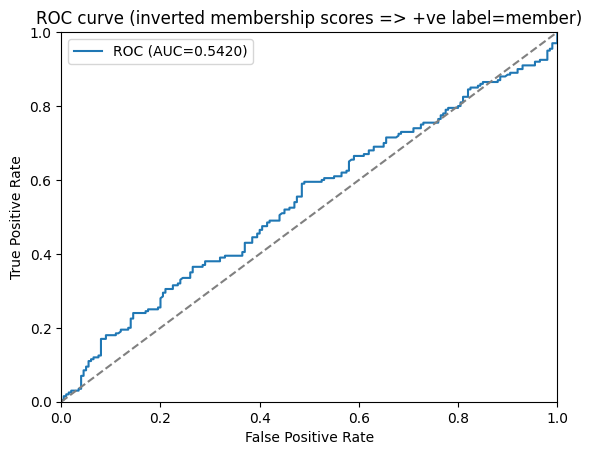


--- Logistic+PCA Attack: fitting logistic model in batch ---


In [ ]:
# ------------------------------------------------------------------------------
# Cell 8: Minimal demonstration (with BATCHES & GPU)
# ------------------------------------------------------------------------------
suite = "pythia"
size  = "70m"
dedup = False
num_texts = 400

print("Fetching model name...")
model_name = get_model_name(suite, size, dedup)
print(f"Loading tokenizer & model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)
model.eval()

print("Loading streaming dataset from 'monology/pile-uncopyrighted' ...")
ds_streaming = load_dataset(
    "monology/pile-uncopyrighted",
    data_files={"train": ["train/00.jsonl.zst"]},  # just the first shard
    streaming=True,
)

print("Filtering to ArXiv subset...")
ds_streaming["train"] = ds_streaming["train"].filter(
    lambda ex: ex["meta"]["pile_set_name"] == "ArXiv"
)

texts = []
for i, example in enumerate(ds_streaming["train"]):
    if i >= num_texts:
        break
    texts.append(example["text"])

print(f"Collected {len(texts)} lines from monology/pile-uncopyrighted, ArXiv subset.")

# We'll define half as members, half as nonmembers
half = len(texts)//2
member_texts   = texts[:half]
nonmember_texts= texts[half:]

print(f"Member set size={len(member_texts)}, Non-member set size={len(nonmember_texts)}")

# Let's do BATCHED Edgington Approach
print("\n--- Edgington Attack: building reference distribution from nonmembers in batch ---")
ref_dict = edgington_fit(
    nonmember_texts, model, tokenizer, device,
    batch_size=4  # or any suitable batch size
)

mem_scores_edg = edgington_score_batch(
    member_texts, model, tokenizer, device, ref_dict,
    batch_size=4
)
nm_scores_edg = edgington_score_batch(
    nonmember_texts, model, tokenizer, device, ref_dict,
    batch_size=4
)

print("Edgington Attack results:")
compute_metrics_and_show(np.array(mem_scores_edg), np.array(nm_scores_edg))

# Let's do BATCHED Logistic approach
print("\n--- Logistic+PCA Attack: fitting logistic model in batch ---")
clf, all_keys, group2pca, group_tags = logistic_fit(
    member_texts, nonmember_texts, model, tokenizer, device,
    batch_size=4
)

mem_scores_log = logistic_score_batch(
    member_texts, model, tokenizer, device, clf, all_keys, group2pca, group_tags,
    batch_size=4
)
nm_scores_log = logistic_score_batch(
    nonmember_texts, model, tokenizer, device, clf, all_keys, group2pca, group_tags,
    batch_size=4
)

print("Logistic+PCA Attack results:")
compute_metrics_and_show(np.array(mem_scores_log), np.array(nm_scores_log))

print("Done.")